In [1]:
import sys
import os

sys.path.append("..")

from src.data_processing import DataProcessingConfig


In [2]:

cfg = DataProcessingConfig()
X_train, X_val, X_test, y_train, y_val, y_test = cfg.preprocess_data()

Train: (64000, 227), Val: (16000, 227), Test: (20000, 227)


In [3]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
import matplotlib.pyplot as plt

# Reproducibility
torch.manual_seed(42)

BATCH_SIZE = 64
EPOCHS = 30
ALPHA=0.001

def make_loaders(x_train, y_train, x_val, y_val, batch_size):
    train_ds = TensorDataset(x_train, y_train)
    val_ds = TensorDataset(x_val, y_val)


    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False
    )

    return train_loader, val_loader

def train_one_epoch(model, loader, loss_fn, optimizer):
    model.train()
    total_loss = 0

    for bx, by in loader:
        pred = model(bx)
        loss = loss_fn(pred, by)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * bx.size(0)

    return total_loss / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader, loss_fn):
    model.eval()
    total_loss = 0
    y_true, y_prob = [], []

    for bx, by in loader:
        logits = model(bx)
        loss = loss_fn(logits, by)
        total_loss += loss.item() * bx.size(0)

        probs = torch.sigmoid(logits)          # logit -> ehtimol (0..1)
        y_true.extend(by.cpu().numpy().ravel())
        y_prob.extend(probs.cpu().numpy().ravel())

    avg_loss = total_loss / len(loader.dataset)

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = (y_prob > 0.5).astype(int)        # threshold 0.5

    accuracy  = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall    = recall_score(y_true, y_pred, zero_division=0)
    f1        = f1_score(y_true, y_pred, zero_division=0)

    return avg_loss, accuracy, precision, recall, f1

def fit_model(model, train_loader, val_loader, optimizer, loss_fn, epochs, early_stop_patience=None):

    train_losses, val_losses = [], []
    best_val = float("inf")
    best_state = None
    patience_left = early_stop_patience

    for epoch in range(1, epochs + 1):
        tr_loss = train_one_epoch(model, train_loader, loss_fn, optimizer)
        val_loss, val_accuracy, val_precision, val_recall, val_f1 = evaluate(model, val_loader, loss_fn)
        

        train_losses.append(tr_loss)
        val_losses.append(val_loss)

        if epoch == 1 or epoch % 10 == 0:
            print(f"Epoch {epoch:03d} | train={tr_loss:.8f} | val={val_loss:.8f}")
            print(f"Accuracy  : {val_accuracy:.4f}")
            print(f"Precision : {val_precision:.4f}")
            print(f"Recall    : {val_recall:.4f}")

        # Early stopping
        if early_stop_patience is not None:
            if val_loss < best_val:
                best_val = val_loss
                patience_left = early_stop_patience

                best_state = model.state_dict()  # Save the best model state
                os.makedirs("models", exist_ok=True)
                torch.save(best_state, "models/best_model.pth")  # Save the best model to a file
            else: 
                patience_left -= 1
                if patience_left <= 0:
                    print(f"Early stop at epoch {epoch} (best val={best_val:.4f})")
                    break

    return train_losses, val_losses


def plot_losses(train_losses, val_losses, title="Loss Curves"):
    plt.figure()
    plt.plot(train_losses, label="Train loss")
    plt.plot(val_losses, label="Val loss")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()


Epoch 001 | train=0.61530672 | val=0.60626232
Accuracy  : 0.6290
Precision : 0.5757
Recall    : 0.7238
Epoch 010 | train=0.59632689 | val=0.60269988
Accuracy  : 0.6304
Precision : 0.5801
Recall    : 0.7000
Epoch 020 | train=0.59060357 | val=0.60334750
Accuracy  : 0.6272
Precision : 0.5898
Recall    : 0.6119
Epoch 030 | train=0.58816631 | val=0.60510508
Accuracy  : 0.6281
Precision : 0.5963
Recall    : 0.5829


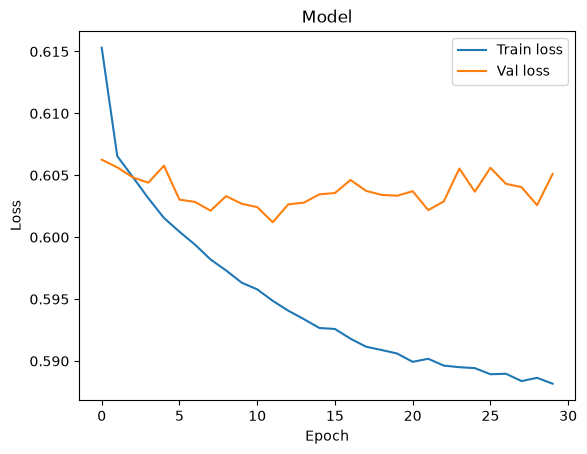

In [4]:
input_dim = X_train.shape[1] # features


train_loader, val_loader = make_loaders(X_train, y_train, X_val, y_val, batch_size=BATCH_SIZE)

model = nn.Sequential(  
    nn.Linear(input_dim, 256), 
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 1), 
)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=ALPHA, weight_decay=1e-3)


train_losses, val_losses = fit_model(model, train_loader, val_loader, optimizer, loss_fn, epochs=EPOCHS)
plot_losses(train_losses, val_losses, title="Model")


Epoch 001 | train=0.63700142 | val=0.61110961
Accuracy  : 0.6278
Precision : 0.5911
Recall    : 0.6091
Epoch 010 | train=0.59989723 | val=0.60371400
Accuracy  : 0.6292
Precision : 0.6018
Recall    : 0.5639
Epoch 020 | train=0.59641464 | val=0.60234763
Accuracy  : 0.6329
Precision : 0.5913
Recall    : 0.6440
Early stop at epoch 21 (best val=0.6021)


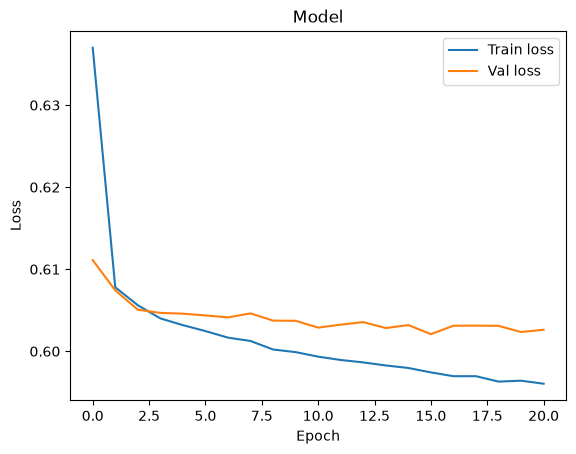

In [18]:
input_dim = X_train.shape[1] # features


train_loader, val_loader = make_loaders(X_train, y_train, X_val, y_val, batch_size=256)

model = nn.Sequential(  
    nn.Linear(input_dim, 128), 
    nn.ReLU(),
    nn.Linear(128, 1), 
)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=ALPHA, weight_decay=1e-3)


train_losses, val_losses = fit_model(model, train_loader, val_loader, optimizer, loss_fn, epochs=40, early_stop_patience=5)
plot_losses(train_losses, val_losses, title="Model")


# Dropout

Epoch 001 | train=0.61421502 | val=0.60333155
Accuracy  : 0.6284
Precision : 0.5861
Recall    : 0.6436
Epoch 010 | train=0.53921255 | val=0.63019219
Accuracy  : 0.6229
Precision : 0.5769
Recall    : 0.6642
Epoch 020 | train=0.47683778 | val=0.70288021
Accuracy  : 0.6128
Precision : 0.5844
Recall    : 0.5366
Epoch 030 | train=0.43977747 | val=0.77220227
Accuracy  : 0.6158
Precision : 0.5806
Recall    : 0.5814


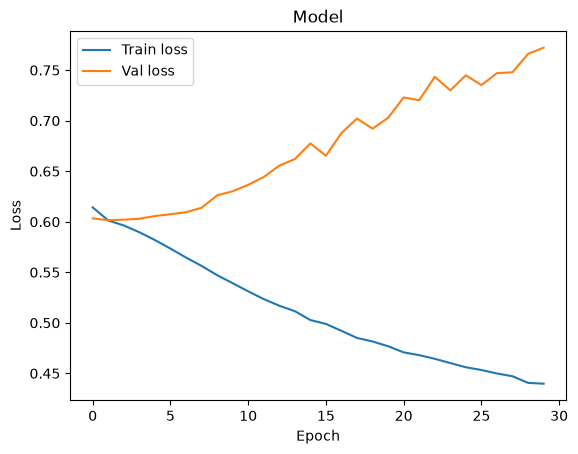

In [5]:
input_dim = X_train.shape[1] # features


train_loader, val_loader = make_loaders(X_train, y_train, X_val, y_val, batch_size=BATCH_SIZE)

model = nn.Sequential(  
    nn.Linear(input_dim, 256), 
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(128, 1), 
)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=ALPHA)


train_losses, val_losses = fit_model(model, train_loader, val_loader, optimizer, loss_fn, epochs=EPOCHS)
plot_losses(train_losses, val_losses, title="Model")


# BatchNorm

Epoch 001 | train=0.61851815 | val=0.60732547
Accuracy  : 0.6226
Precision : 0.5781
Recall    : 0.6526
Epoch 010 | train=0.51723670 | val=0.66198597
Accuracy  : 0.6162
Precision : 0.5810
Recall    : 0.5826
Epoch 020 | train=0.40895246 | val=0.82131425
Accuracy  : 0.6058
Precision : 0.5670
Recall    : 0.5908
Epoch 030 | train=0.35360682 | val=0.93408772
Accuracy  : 0.6018
Precision : 0.5628
Recall    : 0.5871


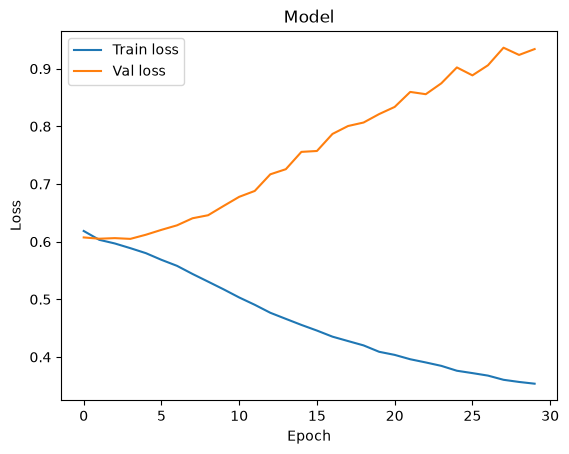

In [6]:
input_dim = X_train.shape[1] # features


train_loader, val_loader = make_loaders(X_train, y_train, X_val, y_val, batch_size=BATCH_SIZE)

model = nn.Sequential(  
    nn.Linear(input_dim, 256), 
    nn.ReLU(),
    nn.BatchNorm1d(256),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.BatchNorm1d(128),
    nn.Linear(128, 1), 
)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=ALPHA)


train_losses, val_losses = fit_model(model, train_loader, val_loader, optimizer, loss_fn, epochs=EPOCHS)
plot_losses(train_losses, val_losses, title="Model")
